<a href="https://colab.research.google.com/github/joaovpitman/Atividade-Avaliativa-01---23/blob/main/AdminAn%C3%A1liseA%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise do Código de Referência - Petrobrás (PETR4)

## Visão Geral

Este código implementa uma análise financeira completa da ação da Petrobrás (PETR4.SA) para o período de **janeiro de 2023 a maio de 2026**. O script demonstra todas as etapas necessárias para baixar, processar, analisar e visualizar dados históricos de ações, servindo como referência para a análise das demais empresas.



📥 Baixando dados da PETR4.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'PETR4.SA'), ('High', 'PETR4.SA'), ('Low', 'PETR4.SA'), ('Open', 'PETR4.SA'), ('Volume', 'PETR4.SA')]
Período: 2023-01-02 até 2026-05-13

📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento     Volume
Date                                                       
2023-01-02     12.80   13.29   12.73       13.14   78424700
2023-01-03     12.47   12.90   12.36       12.81   96750300
2023-01-04     12.87   13.17   12.19       12.26  129504000
2023-01-05     13.33   13.42   12.92       13.03   73886000
2023-01-06     13.25   13.58   13.15       13.37   51851500

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     46.22   46.65   45.20       46.40  71214500
2026-05-08     45.67   46.55   45.67       46.39  32914200
2026-05-11     46.43   46.51   45.65

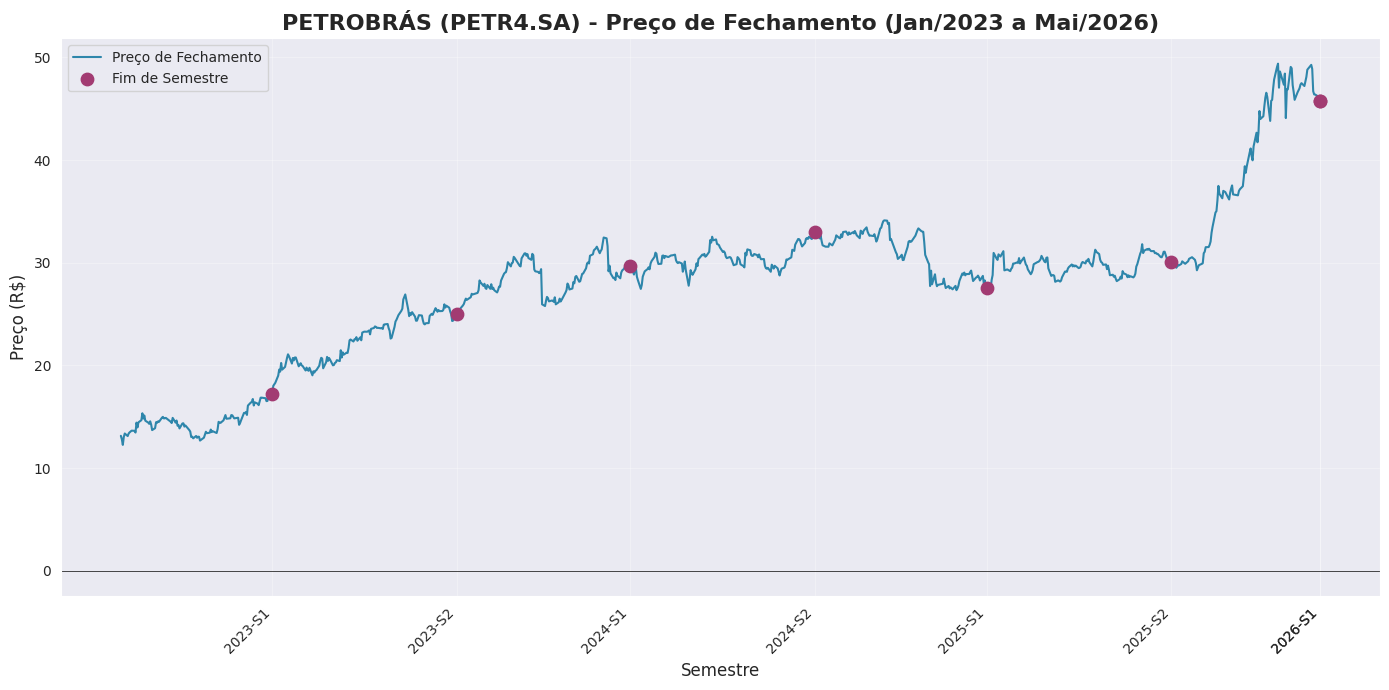


📊 TABELA RESUMO SEMESTRAL
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        13.14          20.77     15.28       2.21      12.26      21.08      58.06
2023       S2        19.91          26.91     23.21       2.25      19.04      26.98      35.14
2024       S1        27.07          30.16     28.84       1.54      25.79      32.46      11.44
2024       S2        30.57          31.70     30.71       1.10      27.77      33.11       3.69
2025       S1        32.26          29.18     30.71       2.17      27.32      34.13      -9.54
2025       S2        29.41          30.38     29.80       0.85      28.15      31.81       3.32
2026       S1        30.54          45.77     40.98       6.39      29.27      49.39      49.86

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!

📈 RESUMO FINAL DO PERÍODO
Preço Inicial (jan/2023): R$ 13.14
Preço Final (mai/2026): R$ 45.77
Retorno Total no período: +248.26%
Volume Médio Diário: 43,917,718 ações


In [1]:
# =====================================================
# ANÁLISE DA PETROBRÁS (PETR4) - JAN/2023 ATÉ MAI/2026
# =====================================================

!pip install yfinance pandas matplotlib seaborn -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ================== 1. BAIXAR DADOS ==================
ticker = "PETR4.SA"
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker} de {start_date} até {end_date}...")

df_petro = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_petro.shape}")
print(f"Colunas disponíveis: {list(df_petro.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_petro.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_petro.index.min().date()} até {df_petro.index.max().date()}")

# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_petro[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_petro[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))

# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_petro['Ano'] = df_petro.index.year
media_anual = df_petro.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual.items():
    print(f"{ano}: R$ {media:.2f}")

# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual = df_petro.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual.items():
    print(f"{ano}: R$ {std:.2f}")

# ================== 5. RETORNO SEMESTRAL ==================
# Adicionar coluna de semestre
df_petro['Semestre'] = df_petro.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_petro['Ano_Semestre'] = df_petro['Ano'].astype(str) + '_' + df_petro['Semestre']

# Calcular retorno semestral (primeiro vs último dia de cada semestre)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre = df_petro.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais = []

for i in range(len(ultimo_dia_semestre) - 1):
    sem_atual = ultimo_dia_semestre.index[i]
    sem_seguinte = ultimo_dia_semestre.index[i+1]

    fechamento_atual = df_petro.loc[ultimo_dia_semestre[i], 'Fechamento']
    fechamento_seguinte = df_petro.loc[ultimo_dia_semestre[i+1], 'Fechamento']

    retorno = ((fechamento_seguinte - fechamento_atual) / fechamento_atual) * 100
    sinal = "+" if retorno >= 0 else ""
    print(f"{sem_atual} → {sem_seguinte}: {sinal}{retorno:.2f}%")

    retornos_semestrais.append({
        'Período': f"{sem_atual} → {sem_seguinte}",
        'Retorno_%': retorno
    })

# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais = []
labels_semestrais = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            # Tentar pegar o último dia do mês (junho ou dezembro)
            data_alvo = pd.Timestamp(f"{ano}-{mes}-{mes}")
            # Buscar o maior índice <= data_alvo
            dados_semestre = df_petro[df_petro.index <= data_alvo]
            if not dados_semestre.empty:
                ultima_data = dados_semestre.index[-1]
                pontos_semestrais.append(ultima_data)
                labels_semestrais.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais = [p for p in pontos_semestrais if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_petro.index, df_petro['Fechamento'], linewidth=1.5, color='#2E86AB', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais:
    valores_semestrais = df_petro.loc[pontos_semestrais, 'Fechamento']
    ax.scatter(pontos_semestrais, valores_semestrais, color='#A23B72', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais:
    ax.set_xticks(pontos_semestrais)
    ax.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais],
                       rotation=45, ha='right')

ax.set_title('PETROBRÁS (PETR4.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Semestre', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# ================== 7. TABELA RESUMO SEMESTRAL ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL")
print("="*80)

# Função para obter último dia de cada semestre
def get_ultimo_dia_semestre(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem = df[df.index <= data_fim]
    if not dados_sem.empty:
        ultima_data = dados_sem.index[-1]
        return ultima_data
    return None

tabela_semestral = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data = get_ultimo_dia_semestre(df_petro, ano, sem)
        if ultima_data and ultima_data <= pd.Timestamp("2026-05-14"):
            dados_sem = df_petro[df_petro.index.year == ano]
            if sem == 'S1':
                dados_sem = dados_sem[dados_sem.index.month <= 6]
            else:
                dados_sem = dados_sem[dados_sem.index.month > 6]

            if not dados_sem.empty:
                abertura = dados_sem['Fechamento'].iloc[0]
                fechamento = dados_sem['Fechamento'].iloc[-1]
                media = dados_sem['Fechamento'].mean()
                desvio = dados_sem['Fechamento'].std()
                minimo = dados_sem['Fechamento'].min()
                maximo = dados_sem['Fechamento'].max()
                retorno = ((fechamento - abertura) / abertura) * 100

                tabela_semestral.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura,
                    'Fechamento_R$': fechamento,
                    'Média_R$': media,
                    'Desvio_R$': desvio,
                    'Mínimo_R$': minimo,
                    'Máximo_R$': maximo,
                    'Retorno_%': retorno
                })

df_tabela = pd.DataFrame(tabela_semestral)
print(df_tabela.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)

# Estatísticas adicionais finais
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO")
print("="*80)
preco_inicial = df_petro['Fechamento'].iloc[0]
preco_final = df_petro['Fechamento'].iloc[-1]
retorno_total = ((preco_final - preco_inicial) / preco_inicial) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final:.2f}")
print(f"Retorno Total no período: {retorno_total:+.2f}%")
print(f"Volume Médio Diário: {df_petro['Volume'].mean():,.0f} ações")

## Análise da VALE S.A. (VALE3.SA)

In [2]:
# =====================================================
# ANÁLISE DA VALE S.A. (VALE3.SA) - JAN/2023 ATÉ MAI/2026
# =====================================================

ticker_vale = "VALE3.SA"
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker_vale} de {start_date} até {end_date}...")

df_vale = yf.download(ticker_vale, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_vale.shape}")
print(f"Colunas disponíveis: {list(df_vale.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_vale.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_vale.index.min().date()} até {df_vale.index.max().date()}")

📥 Baixando dados da VALE3.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'VALE3.SA'), ('High', 'VALE3.SA'), ('Low', 'VALE3.SA'), ('Open', 'VALE3.SA'), ('Volume', 'VALE3.SA')]
Período: 2023-01-02 até 2026-05-13


In [3]:
# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_vale[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_vale[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))


📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     66.62   66.99   65.97       66.08  12783800
2023-01-03     66.50   67.13   66.24       66.62  25332600
2023-01-04     66.62   66.80   65.54       66.54  26395300
2023-01-05     67.73   68.32   66.32       66.66  29085600
2023-01-06     68.81   69.11   67.81       67.81  31420600

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     80.07   81.67   79.60       81.29  18912100
2026-05-08     80.80   81.79   80.36       80.57  16782600
2026-05-11     83.45   83.93   81.19       81.39  24868900
2026-05-12     83.25   83.99   81.74       83.15  16503000
2026-05-13     84.30   85.05   83.01       83.49  31641800


In [4]:
# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_vale['Ano'] = df_vale.index.year
media_anual_vale = df_vale.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual_vale.items():
    print(f"{ano}: R$ {media:.2f}")


📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)
2023: R$ 56.94
2024: R$ 52.82
2025: R$ 53.13
2026: R$ 82.53


In [5]:
# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual_vale = df_vale.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual_vale.items():
    print(f"{ano}: R$ {std:.2f}")


📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)
2023: R$ 6.44
2024: R$ 2.47
2025: R$ 6.30
2026: R$ 4.58


In [6]:
# ================== 5. RETORNO SEMESTRAL ==================
# Adicionar coluna de semestre
df_vale['Semestre'] = df_vale.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_vale['Ano_Semestre'] = df_vale['Ano'].astype(str) + '_' + df_vale['Semestre']

# Calcular retorno semestral (primeiro vs último dia de cada semestre)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre_vale = df_vale.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais_vale = []

for i in range(len(ultimo_dia_semestre_vale) - 1):
    sem_atual_vale = ultimo_dia_semestre_vale.index[i]
    sem_seguinte_vale = ultimo_dia_semestre_vale.index[i+1]

    fechamento_atual_vale = df_vale.loc[ultimo_dia_semestre_vale[i], 'Fechamento']
    fechamento_seguinte_vale = df_vale.loc[ultimo_dia_semestre_vale[i+1], 'Fechamento']

    retorno_vale = ((fechamento_seguinte_vale - fechamento_atual_vale) / fechamento_atual_vale) * 100
    sinal_vale = "+" if retorno_vale >= 0 else ""
    print(f"{sem_atual_vale} → {sem_seguinte_vale}: {sinal_vale}{retorno_vale:.2f}%")

    retornos_semestrais_vale.append({
        'Período': f"{sem_atual_vale} → {sem_seguinte_vale}",
        'Retorno_%': retorno_vale
    })


📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)
2023_S1 → 2023_S2: +24.44%
2023_S2 → 2024_S1: -16.31%
2024_S1 → 2024_S2: -6.92%
2024_S2 → 2025_S1: -0.09%
2025_S1 → 2025_S2: +49.60%
2025_S2 → 2026_S1: +15.16%


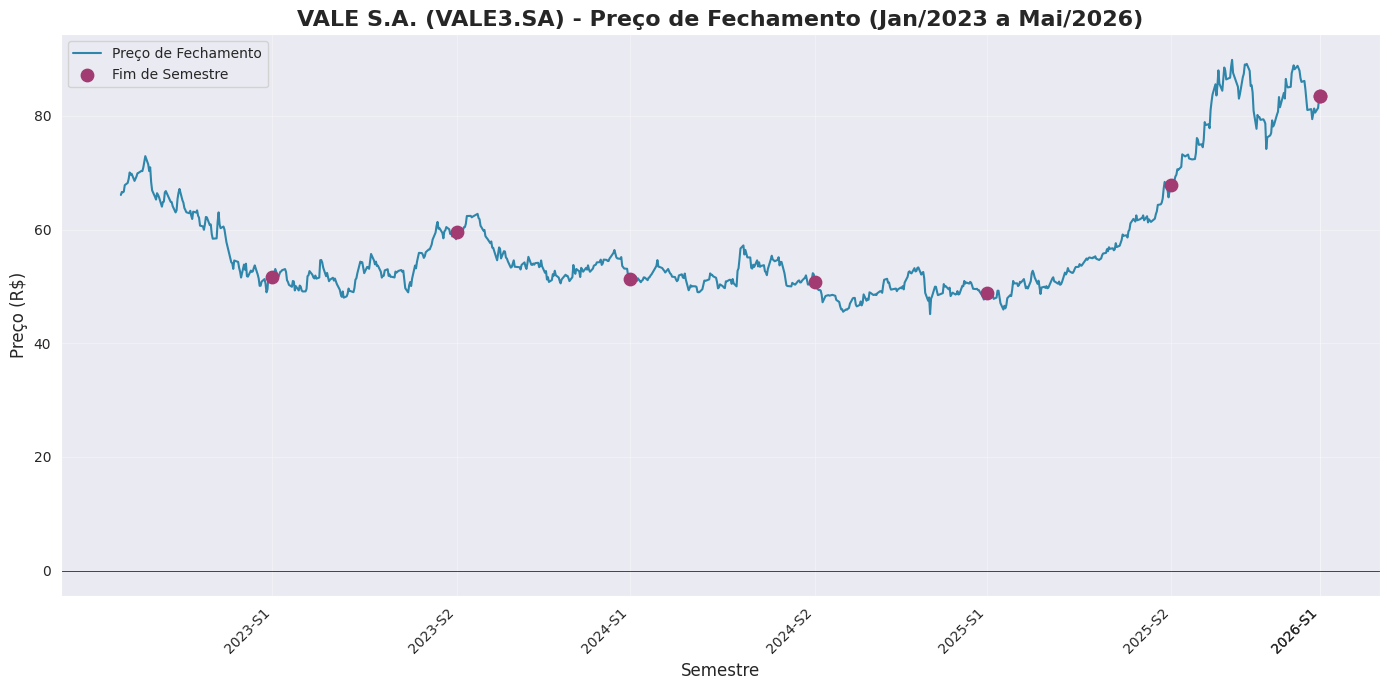

In [7]:
# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais_vale = []
labels_semestrais_vale = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            # Tentar pegar o último dia do mês (junho ou dezembro)
            data_alvo_vale = pd.Timestamp(f"{ano}-{mes}-{mes}")
            # Buscar o maior índice <= data_alvo
            dados_semestre_vale = df_vale[df_vale.index <= data_alvo_vale]
            if not dados_semestre_vale.empty:
                ultima_data_vale = dados_semestre_vale.index[-1]
                pontos_semestrais_vale.append(ultima_data_vale)
                labels_semestrais_vale.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais_vale = [p for p in pontos_semestrais_vale if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig_vale, ax_vale = plt.subplots(figsize=(14, 7))

ax_vale.plot(df_vale.index, df_vale['Fechamento'], linewidth=1.5, color='#2E86AB', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais_vale:
    valores_semestrais_vale = df_vale.loc[pontos_semestrais_vale, 'Fechamento']
    ax_vale.scatter(pontos_semestrais_vale, valores_semestrais_vale, color='#A23B72', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais_vale:
    ax_vale.set_xticks(pontos_semestrais_vale)
    ax_vale.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais_vale],
                       rotation=45, ha='right')

ax_vale.set_title('VALE S.A. (VALE3.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax_vale.set_xlabel('Semestre', fontsize=12)
ax_vale.set_ylabel('Preço (R$)', fontsize=12)
ax_vale.legend(loc='upper left')
ax_vale.grid(True, alpha=0.3)
ax_vale.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [8]:
# ================== 7. TABELA RESUMO SEMESTRAL ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL")
print("="*80)

# Função para obter último dia de cada semestre (redefinida para VALE)
def get_ultimo_dia_semestre_vale(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem_vale = df[df.index <= data_fim]
    if not dados_sem_vale.empty:
        ultima_data_vale = dados_sem_vale.index[-1]
        return ultima_data_vale
    return None

tabela_semestral_vale = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data_vale = get_ultimo_dia_semestre_vale(df_vale, ano, sem)
        if ultima_data_vale and ultima_data_vale <= pd.Timestamp("2026-05-14"):
            dados_sem_periodo_vale = df_vale[df_vale.index.year == ano]
            if sem == 'S1':
                dados_sem_periodo_vale = dados_sem_periodo_vale[dados_sem_periodo_vale.index.month <= 6]
            else:
                dados_sem_periodo_vale = dados_sem_periodo_vale[dados_sem_periodo_vale.index.month > 6]

            if not dados_sem_periodo_vale.empty:
                abertura_vale = dados_sem_periodo_vale['Fechamento'].iloc[0]
                fechamento_vale = dados_sem_periodo_vale['Fechamento'].iloc[-1]
                media_vale = dados_sem_periodo_vale['Fechamento'].mean()
                desvio_vale = dados_sem_periodo_vale['Fechamento'].std()
                minimo_vale = dados_sem_periodo_vale['Fechamento'].min()
                maximo_vale = dados_sem_periodo_vale['Fechamento'].max()
                retorno_vale_calc = ((fechamento_vale - abertura_vale) / abertura_vale) * 100

                tabela_semestral_vale.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura_vale,
                    'Fechamento_R$': fechamento_vale,
                    'Média_R$': media_vale,
                    'Desvio_R$': desvio_vale,
                    'Mínimo_R$': minimo_vale,
                    'Máximo_R$': maximo_vale,
                    'Retorno_%': retorno_vale_calc
                })

df_tabela_vale = pd.DataFrame(tabela_semestral_vale)
print(df_tabela_vale.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)


📊 TABELA RESUMO SEMESTRAL
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        66.08          50.04     59.96       7.04      48.95      72.91     -24.27
2023       S2        49.28          62.27     53.92       3.93      48.01      62.40      26.36
2024       S1        62.76          52.11     53.86       2.48      50.52      62.76     -16.96
2024       S2        52.98          48.51     51.81       2.00      47.20      57.20      -8.45
2025       S1        48.34          48.46     49.03       1.84      45.12      53.34       0.26
2025       S2        48.29          72.50     57.04       6.56      48.29      73.23      50.14
2026       S1        72.33          83.49     82.53       4.58      72.33      89.85      15.43

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!


In [9]:
# Estatísticas adicionais finais
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO")
print("="*80)
preco_inicial_vale = df_vale['Fechamento'].iloc[0]
preco_final_vale = df_vale['Fechamento'].iloc[-1]
retorno_total_vale = ((preco_final_vale - preco_inicial_vale) / preco_inicial_vale) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial_vale:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final_vale:.2f}")
print(f"Retorno Total no período: {retorno_total_vale:+.2f}%")
print(f"Volume Médio Diário: {df_vale['Volume'].mean():,.0f} ações")


📈 RESUMO FINAL DO PERÍODO
Preço Inicial (jan/2023): R$ 66.08
Preço Final (mai/2026): R$ 83.49
Retorno Total no período: +26.35%
Volume Médio Diário: 24,182,592 ações


## 📈 Análise Comparativa: PETR4.SA vs VALE3.SA

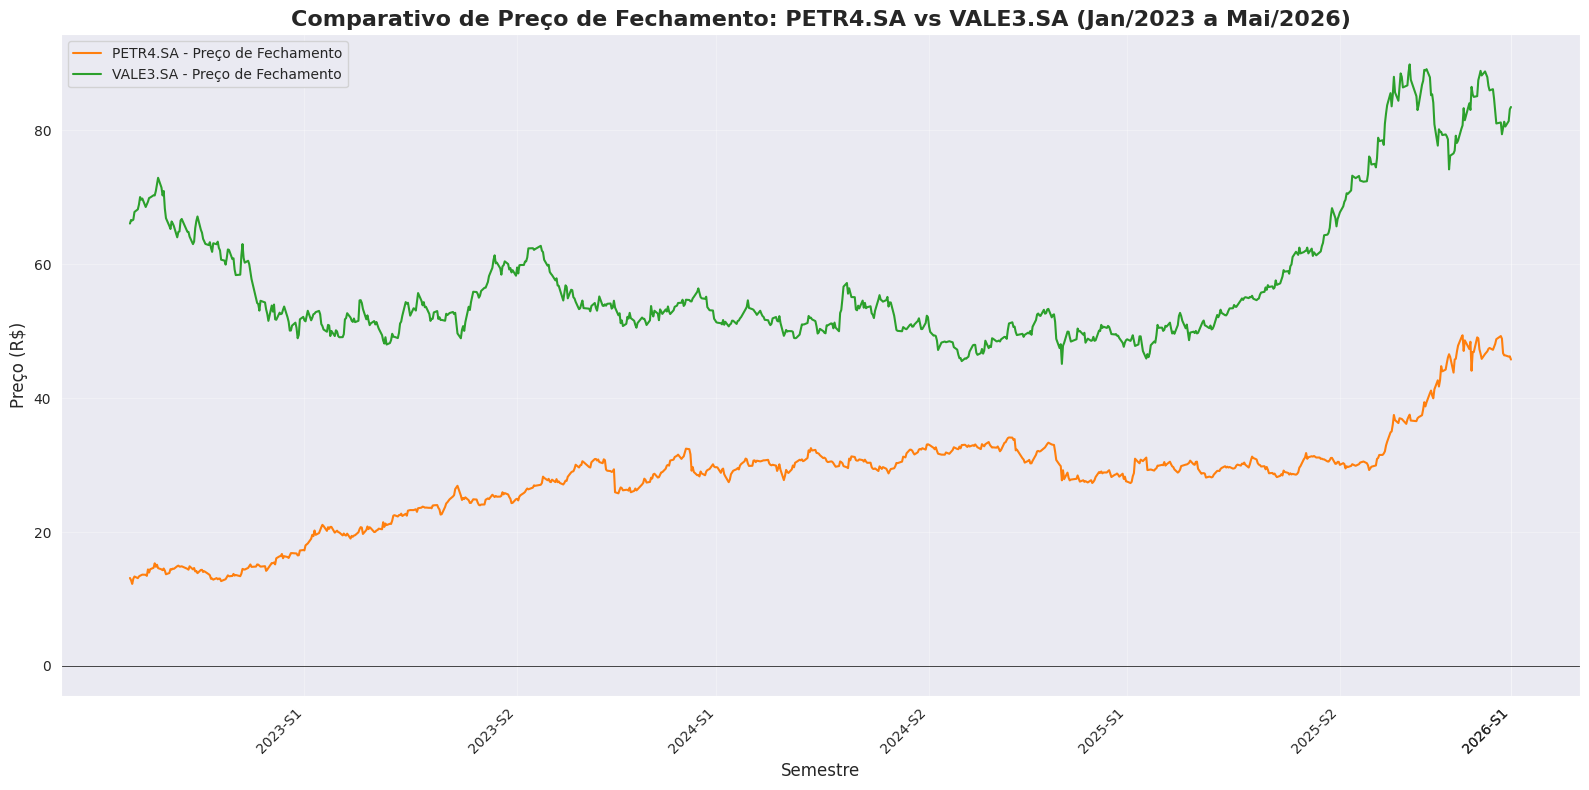

In [10]:
# ================== GRÁFICO COMPARATIVO PETR4 vs VALE3 ==================

fig_comp, ax_comp = plt.subplots(figsize=(16, 8))

# Plotar PETR4
ax_comp.plot(df_petro.index, df_petro['Fechamento'], linewidth=1.5, color='#FF7F0E', label='PETR4.SA - Preço de Fechamento')
# Plotar VALE3
ax_comp.plot(df_vale.index, df_vale['Fechamento'], linewidth=1.5, color='#2CA02C', label='VALE3.SA - Preço de Fechamento')

# Configurar eixo X com semestres (usando os mesmos pontos semestrais de PETR4 ou VALE3)
if pontos_semestrais:
    ax_comp.set_xticks(pontos_semestrais)
    ax_comp.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais],
                       rotation=45, ha='right')

ax_comp.set_title('Comparativo de Preço de Fechamento: PETR4.SA vs VALE3.SA (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax_comp.set_xlabel('Semestre', fontsize=12)
ax_comp.set_ylabel('Preço (R$)', fontsize=12)
ax_comp.legend(loc='upper left', fontsize=10)
ax_comp.grid(True, alpha=0.3)
ax_comp.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## Análise da Ambev S.A. (ABEV3.SA)

In [11]:
# =====================================================
# ANÁLISE DA AMBEV S.A. (ABEV3.SA) - JAN/2023 ATÉ MAI/2026
# =====================================================

ticker_ambev = "ABEV3.SA"

print(f"📥 Baixando dados da {ticker_ambev} de {start_date} até {end_date}...")

df_ambev = yf.download(ticker_ambev, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_ambev.shape}")
print(f"Colunas disponíveis: {list(df_ambev.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_ambev.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_ambev.index.min().date()} até {df_ambev.index.max().date()}")

📥 Baixando dados da ABEV3.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'ABEV3.SA'), ('High', 'ABEV3.SA'), ('Low', 'ABEV3.SA'), ('Open', 'ABEV3.SA'), ('Volume', 'ABEV3.SA')]
Período: 2023-01-02 até 2026-05-13


In [12]:
# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS (ABEV3.SA)")
print("="*80)
print(df_ambev[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS (ABEV3.SA)")
print("="*80)
print(df_ambev[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))


📋 5 PRIMEIRAS LINHAS (ABEV3.SA)
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     12.00   12.22   11.85       12.17  14995900
2023-01-03     11.98   12.17   11.93       11.97  36363800
2023-01-04     12.05   12.23   11.90       12.07  23791800
2023-01-05     12.08   12.18   11.95       12.06  31031500
2023-01-06     12.11   12.14   11.97       12.09  20889800

📋 5 ÚLTIMAS LINHAS (ABEV3.SA)
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     16.41   17.04   16.32       16.86  30952400
2026-05-08     16.32   16.55   16.18       16.49  41784100
2026-05-11     16.25   16.50   16.17       16.20  19740000
2026-05-12     16.13   16.32   16.10       16.21  19751300
2026-05-13     15.91   16.30   15.85       16.16  28456100


In [13]:
# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO (ABEV3.SA) ==================
df_ambev['Ano'] = df_ambev.index.year
media_anual_ambev = df_ambev.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (ABEV3.SA - R$)")
print("="*80)
for ano, media in media_anual_ambev.items():
    print(f"{ano}: R$ {media:.2f}")


📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (ABEV3.SA - R$)
2023: R$ 11.89
2024: R$ 11.16
2025: R$ 12.25
2026: R$ 15.18


In [14]:
# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (ABEV3.SA) ==================
std_anual_ambev = df_ambev.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (ABEV3.SA - R$)")
print("="*80)
for ano, std in std_anual_ambev.items():
    print(f"{ano}: R$ {std:.2f}")


📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (ABEV3.SA - R$)
2023: R$ 0.63
2024: R$ 0.61
2025: R$ 1.04
2026: R$ 0.80


In [15]:
# ================== 5. RETORNO SEMESTRAL (ABEV3.SA) ==================
# Adicionar coluna de semestre
df_ambev['Semestre'] = df_ambev.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_ambev['Ano_Semestre'] = df_ambev['Ano'].astype(str) + '_' + df_ambev['Semestre']

# Calcular retorno semestral (primeiro vs último dia de cada semestre)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (ABEV3.SA - %)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre_ambev = df_ambev.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais_ambev = []

for i in range(len(ultimo_dia_semestre_ambev) - 1):
    sem_atual_ambev = ultimo_dia_semestre_ambev.index[i]
    sem_seguinte_ambev = ultimo_dia_semestre_ambev.index[i+1]

    fechamento_atual_ambev = df_ambev.loc[ultimo_dia_semestre_ambev[i], 'Fechamento']
    fechamento_seguinte_ambev = df_ambev.loc[ultimo_dia_semestre_ambev[i+1], 'Fechamento']

    retorno_ambev = ((fechamento_seguinte_ambev - fechamento_atual_ambev) / fechamento_atual_ambev) * 100
    sinal_ambev = "+" if retorno_ambev >= 0 else ""
    print(f"{sem_atual_ambev} → {sem_seguinte_ambev}: {sinal_ambev}{retorno_ambev:.2f}%")

    retornos_semestrais_ambev.append({
        'Período': f"{sem_atual_ambev} → {sem_seguinte_ambev}",
        'Retorno_%': retorno_ambev
    })


📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (ABEV3.SA - %)
2023_S1 → 2023_S2: -5.40%
2023_S2 → 2024_S1: -17.17%
2024_S1 → 2024_S2: +11.33%
2024_S2 → 2025_S1: +10.55%
2025_S1 → 2025_S2: +11.07%
2025_S2 → 2026_S1: +16.26%


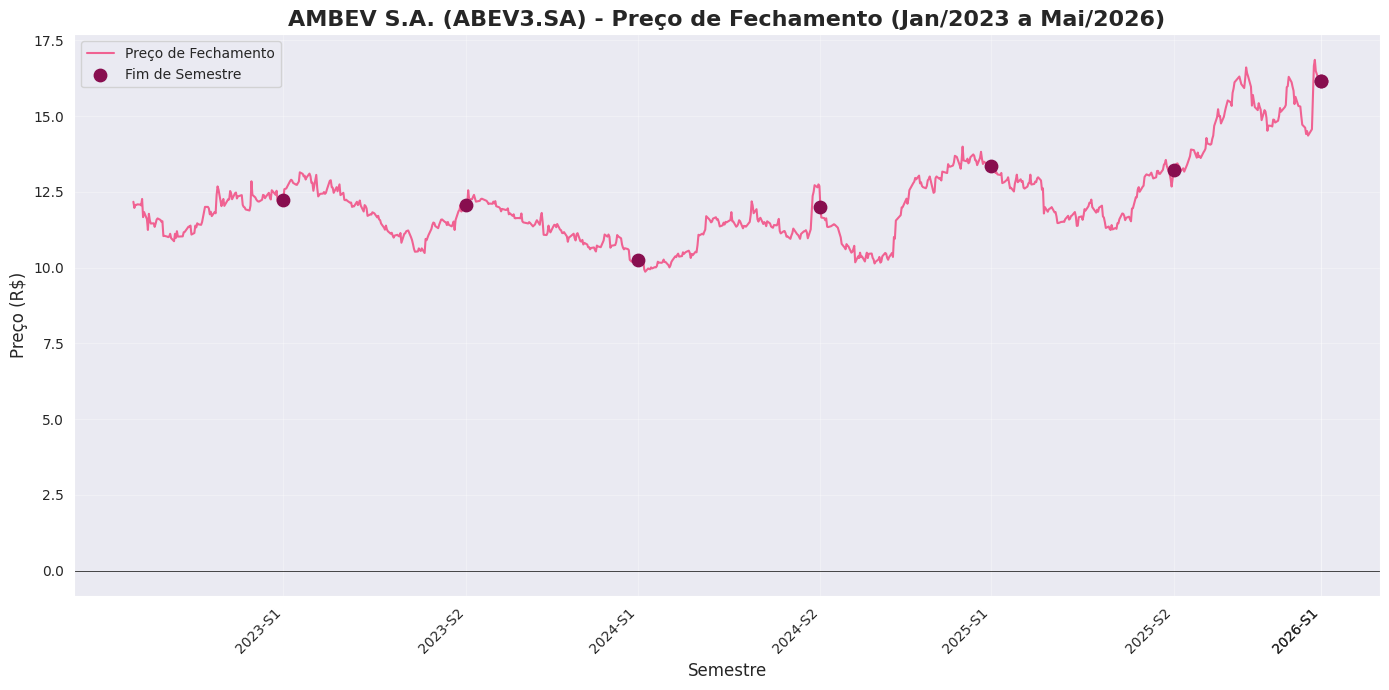

In [16]:
# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL (ABEV3.SA) ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais_ambev = []
labels_semestrais_ambev = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            # Tentar pegar o último dia do mês (junho ou dezembro)
            data_alvo_ambev = pd.Timestamp(f"{ano}-{mes}-{mes}")
            # Buscar o maior índice <= data_alvo
            dados_semestre_ambev = df_ambev[df_ambev.index <= data_alvo_ambev]
            if not dados_semestre_ambev.empty:
                ultima_data_ambev = dados_semestre_ambev.index[-1]
                pontos_semestrais_ambev.append(ultima_data_ambev)
                labels_semestrais_ambev.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais_ambev = [p for p in pontos_semestrais_ambev if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig_ambev, ax_ambev = plt.subplots(figsize=(14, 7))

ax_ambev.plot(df_ambev.index, df_ambev['Fechamento'], linewidth=1.5, color='#F06292', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais_ambev:
    valores_semestrais_ambev = df_ambev.loc[pontos_semestrais_ambev, 'Fechamento']
    ax_ambev.scatter(pontos_semestrais_ambev, valores_semestrais_ambev, color='#880E4F', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais_ambev:
    ax_ambev.set_xticks(pontos_semestrais_ambev)
    ax_ambev.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais_ambev],
                       rotation=45, ha='right')

ax_ambev.set_title('AMBEV S.A. (ABEV3.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax_ambev.set_xlabel('Semestre', fontsize=12)
ax_ambev.set_ylabel('Preço (R$)', fontsize=12)
ax_ambev.legend(loc='upper left')
ax_ambev.grid(True, alpha=0.3)
ax_ambev.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [17]:
# ================== 7. TABELA RESUMO SEMESTRAL (ABEV3.SA) ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL (ABEV3.SA)")
print("="*80)

# Função para obter último dia de cada semestre (reutilizada e adaptada)
def get_ultimo_dia_semestre_ambev(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem_ambev = df[df.index <= data_fim]
    if not dados_sem_ambev.empty:
        ultima_data_ambev = dados_sem_ambev.index[-1]
        return ultima_data_ambev
    return None

tabela_semestral_ambev = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data_ambev = get_ultimo_dia_semestre_ambev(df_ambev, ano, sem)
        if ultima_data_ambev and ultima_data_ambev <= pd.Timestamp("2026-05-14"):
            dados_sem_periodo_ambev = df_ambev[df_ambev.index.year == ano]
            if sem == 'S1':
                dados_sem_periodo_ambev = dados_sem_periodo_ambev[dados_sem_periodo_ambev.index.month <= 6]
            else:
                dados_sem_periodo_ambev = dados_sem_periodo_ambev[dados_sem_periodo_ambev.index.month > 6]

            if not dados_sem_periodo_ambev.empty:
                abertura_ambev = dados_sem_periodo_ambev['Fechamento'].iloc[0]
                fechamento_ambev = dados_sem_periodo_ambev['Fechamento'].iloc[-1]
                media_ambev = dados_sem_periodo_ambev['Fechamento'].mean()
                desvio_ambev = dados_sem_periodo_ambev['Fechamento'].std()
                minimo_ambev = dados_sem_periodo_ambev['Fechamento'].min()
                maximo_ambev = dados_sem_periodo_ambev['Fechamento'].max()
                retorno_ambev_calc = ((fechamento_ambev - abertura_ambev) / abertura_ambev) * 100

                tabela_semestral_ambev.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura_ambev,
                    'Fechamento_R$': fechamento_ambev,
                    'Média_R$': media_ambev,
                    'Desvio_R$': desvio_ambev,
                    'Mínimo_R$': minimo_ambev,
                    'Máximo_R$': maximo_ambev,
                    'Retorno_%': retorno_ambev_calc
                })

df_tabela_ambev = pd.DataFrame(tabela_semestral_ambev)
print(df_tabela_ambev.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA PARA ABEV3.SA!")
print("="*80)


📊 TABELA RESUMO SEMESTRAL (ABEV3.SA)
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        12.17          12.98     11.99       0.58      10.87      13.15       6.60
2023       S2        13.10          12.28     11.78       0.65      10.48      13.10      -6.31
2024       S1        12.21          10.17     11.07       0.62       9.87      12.21     -16.69
2024       S2        10.16          11.32     11.24       0.58      10.01      12.75      11.42
2025       S1        11.00          12.51     12.18       1.30      10.14      14.00      13.75
2025       S2        12.77          13.90     12.31       0.71      11.24      13.90       8.82
2026       S1        13.88          16.16     15.18       0.80      13.62      16.86      16.43

🎉 ANÁLISE CONCLUÍDA PARA ABEV3.SA!


In [18]:
# Estatísticas adicionais finais (ABEV3.SA)
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO (ABEV3.SA)")
print("="*80)
preco_inicial_ambev = df_ambev['Fechamento'].iloc[0]
preco_final_ambev = df_ambev['Fechamento'].iloc[-1]
retorno_total_ambev = ((preco_final_ambev - preco_inicial_ambev) / preco_inicial_ambev) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial_ambev:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final_ambev:.2f}")
print(f"Retorno Total no período: {retorno_total_ambev:+.2f}%")
print(f"Volume Médio Diário: {df_ambev['Volume'].mean():,.0f} ações")


📈 RESUMO FINAL DO PERÍODO (ABEV3.SA)
Preço Inicial (jan/2023): R$ 12.17
Preço Final (mai/2026): R$ 16.16
Retorno Total no período: +32.73%
Volume Médio Diário: 29,107,495 ações


## Análise do Itaú Unibanco (ITUB4.SA)

In [19]:
# =====================================================
# ANÁLISE DO ITAÚ UNIBANCO (ITUB4.SA) - JAN/2023 ATÉ MAI/2026
# =====================================================

ticker_itau = "ITUB4.SA"

print(f"📥 Baixando dados da {ticker_itau} de {start_date} até {end_date}...")

df_itau = yf.download(ticker_itau, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_itau.shape}")
print(f"Colunas disponíveis: {list(df_itau.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_itau.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_itau.index.min().date()} até {df_itau.index.max().date()}")

📥 Baixando dados da ITUB4.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'ITUB4.SA'), ('High', 'ITUB4.SA'), ('Low', 'ITUB4.SA'), ('Open', 'ITUB4.SA'), ('Volume', 'ITUB4.SA')]
Período: 2023-01-02 até 2026-05-13


In [20]:
# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS (ITUB4.SA) ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS (ITUB4.SA)")
print("="*80)
print(df_itau[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS (ITUB4.SA)")
print("="*80)
print(df_itau[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))


📋 5 PRIMEIRAS LINHAS (ITUB4.SA)
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     16.78   16.81   16.47       16.74  26445013
2023-01-03     16.43   16.89   16.33       16.78  33847015
2023-01-04     16.48   16.80   16.36       16.48  33855739
2023-01-05     16.99   17.07   16.46       16.51  41153732
2023-01-06     17.29   17.34   16.99       17.08  42632750

📋 5 ÚLTIMAS LINHAS (ITUB4.SA)
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     40.79   41.87   40.52       41.79  36335300
2026-05-08     41.26   41.55   40.98       41.16  35920000
2026-05-11     40.33   41.11   40.11       40.95  41215600
2026-05-12     39.87   40.33   39.77       40.29  43381700
2026-05-13     39.63   40.57   39.37       39.93  48564700


In [21]:
# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO (ITUB4.SA) ==================
df_itau['Ano'] = df_itau.index.year
media_anual_itau = df_itau.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (ITUB4.SA - R$)")
print("="*80)
for ano, media in media_anual_itau.items():
    print(f"{ano}: R$ {media:.2f}")


📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (ITUB4.SA - R$)
2023: R$ 19.12
2024: R$ 25.37
2025: R$ 31.89
2026: R$ 43.61


In [22]:
# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (ITUB4.SA) ==================
std_anual_itau = df_itau.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (ITUB4.SA - R$)")
print("="*80)
for ano, std in std_anual_itau.items():
    print(f"{ano}: R$ {std:.2f}")


📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (ITUB4.SA - R$)
2023: R$ 1.78
2024: R$ 1.42
2025: R$ 4.05
2026: R$ 2.75


In [23]:
# ================== 5. RETORNO SEMESTRAL (ITUB4.SA) ==================
# Adicionar coluna de semestre
df_itau['Semestre'] = df_itau.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_itau['Ano_Semestre'] = df_itau['Ano'].astype(str) + '_' + df_itau['Semestre']

# Calcular retorno semestral (primeiro vs último dia de cada semestre)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (ITUB4.SA - %)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre_itau = df_itau.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais_itau = []

for i in range(len(ultimo_dia_semestre_itau) - 1):
    sem_atual_itau = ultimo_dia_semestre_itau.index[i]
    sem_seguinte_itau = ultimo_dia_semestre_itau.index[i+1]

    fechamento_atual_itau = df_itau.loc[ultimo_dia_semestre_itau[i], 'Fechamento']
    fechamento_seguinte_itau = df_itau.loc[ultimo_dia_semestre_itau[i+1], 'Fechamento']

    retorno_itau = ((fechamento_seguinte_itau - fechamento_atual_itau) / fechamento_atual_itau) * 100
    sinal_itau = "+" if retorno_itau >= 0 else ""
    print(f"{sem_atual_itau} → {sem_seguinte_itau}: {sinal_itau}{retorno_itau:.2f}%")

    retornos_semestrais_itau.append({
        'Período': f"{sem_atual_itau} → {sem_seguinte_itau}",
        'Retorno_%': retorno_itau
    })


📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (ITUB4.SA - %)
2023_S1 → 2023_S2: +20.32%
2023_S2 → 2024_S1: +0.82%
2024_S1 → 2024_S2: -3.03%
2024_S2 → 2025_S1: +36.64%
2025_S1 → 2025_S2: +19.65%
2025_S2 → 2026_S1: +2.84%


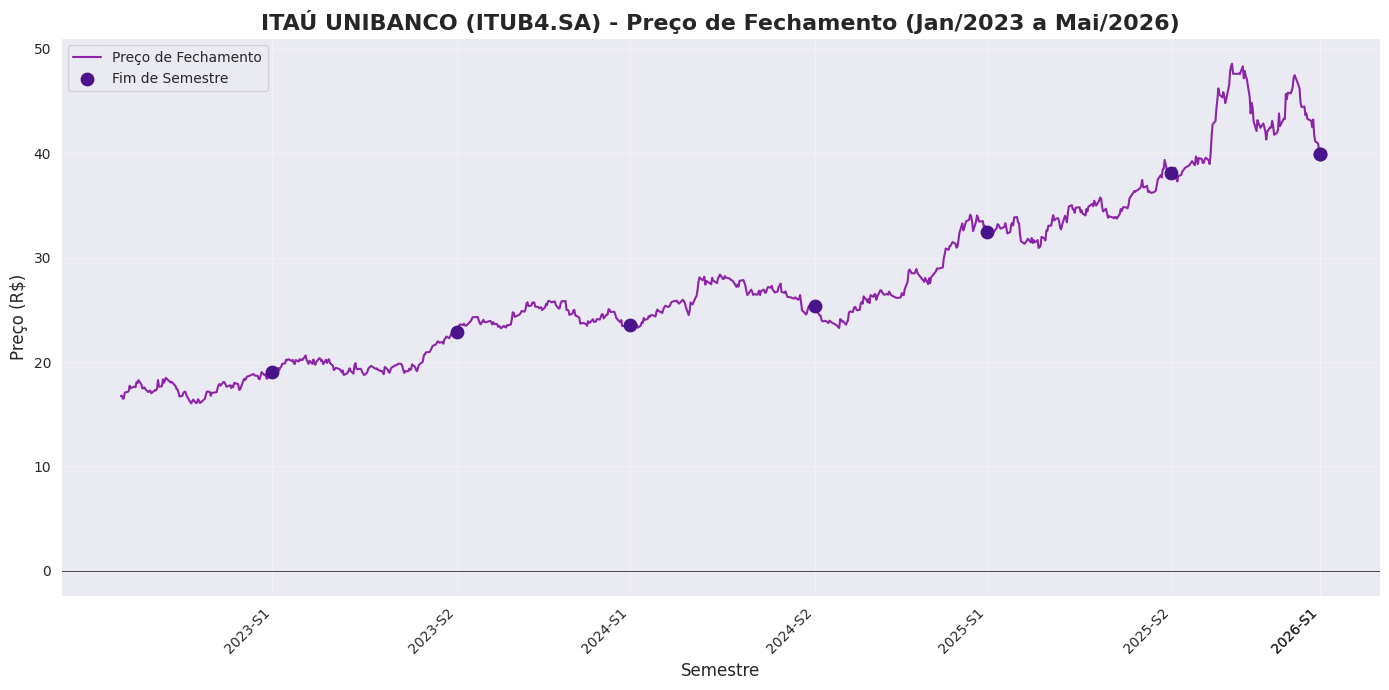

In [24]:
# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL (ITUB4.SA) ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais_itau = []
labels_semestrais_itau = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            # Tentar pegar o último dia do mês (junho ou dezembro)
            data_alvo_itau = pd.Timestamp(f"{ano}-{mes}-{mes}")
            # Buscar o maior índice <= data_alvo
            dados_semestre_itau = df_itau[df_itau.index <= data_alvo_itau]
            if not dados_semestre_itau.empty:
                ultima_data_itau = dados_semestre_itau.index[-1]
                pontos_semestrais_itau.append(ultima_data_itau)
                labels_semestrais_itau.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais_itau = [p for p in pontos_semestrais_itau if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig_itau, ax_itau = plt.subplots(figsize=(14, 7))

ax_itau.plot(df_itau.index, df_itau['Fechamento'], linewidth=1.5, color='#8E24AA', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais_itau:
    valores_semestrais_itau = df_itau.loc[pontos_semestrais_itau, 'Fechamento']
    ax_itau.scatter(pontos_semestrais_itau, valores_semestrais_itau, color='#4A148C', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais_itau:
    ax_itau.set_xticks(pontos_semestrais_itau)
    ax_itau.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais_itau],
                       rotation=45, ha='right')

ax_itau.set_title('ITAÚ UNIBANCO (ITUB4.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax_itau.set_xlabel('Semestre', fontsize=12)
ax_itau.set_ylabel('Preço (R$)', fontsize=12)
ax_itau.legend(loc='upper left')
ax_itau.grid(True, alpha=0.3)
ax_itau.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [25]:
# ================== 7. TABELA RESUMO SEMESTRAL (ITUB4.SA) ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL (ITUB4.SA)")
print("="*80)

# Função para obter último dia de cada semestre (reutilizada e adaptada)
def get_ultimo_dia_semestre_itau(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem_itau = df[df.index <= data_fim]
    if not dados_sem_itau.empty:
        ultima_data_itau = dados_sem_itau.index[-1]
        return ultima_data_itau
    return None

tabela_semestral_itau = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data_itau = get_ultimo_dia_semestre_itau(df_itau, ano, sem)
        if ultima_data_itau and ultima_data_itau <= pd.Timestamp("2026-05-14"):
            dados_sem_periodo_itau = df_itau[df_itau.index.year == ano]
            if sem == 'S1':
                dados_sem_periodo_itau = dados_sem_periodo_itau[dados_sem_periodo_itau.index.month <= 6]
            else:
                dados_sem_periodo_itau = dados_sem_periodo_itau[dados_sem_periodo_itau.index.month > 6]

            if not dados_sem_periodo_itau.empty:
                abertura_itau = dados_sem_periodo_itau['Fechamento'].iloc[0]
                fechamento_itau = dados_sem_periodo_itau['Fechamento'].iloc[-1]
                media_itau = dados_sem_periodo_itau['Fechamento'].mean()
                desvio_itau = dados_sem_periodo_itau['Fechamento'].std()
                minimo_itau = dados_sem_periodo_itau['Fechamento'].min()
                maximo_itau = dados_sem_periodo_itau['Fechamento'].max()
                retorno_itau_calc = ((fechamento_itau - abertura_itau) / abertura_itau) * 100

                tabela_semestral_itau.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura_itau,
                    'Fechamento_R$': fechamento_itau,
                    'Média_R$': media_itau,
                    'Desvio_R$': desvio_itau,
                    'Mínimo_R$': minimo_itau,
                    'Máximo_R$': maximo_itau,
                    'Retorno_%': retorno_itau_calc
                })

df_tabela_itau = pd.DataFrame(tabela_semestral_itau)
print(df_tabela_itau.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA PARA ITUB4.SA!")
print("="*80)


📊 TABELA RESUMO SEMESTRAL (ITUB4.SA)
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        16.74          20.19     17.88       1.07      16.03      20.26      20.63
2023       S2        20.04          24.29     20.36       1.46      18.74      24.29      21.21
2024       S1        24.31          24.49     24.38       0.77      23.23      25.86       0.74
2024       S2        24.43          23.75     26.33       1.23      23.74      28.38      -2.78
2025       S1        23.59          32.45     28.84       3.27      23.26      34.12      37.54
2025       S2        33.17          38.83     34.81       2.11      30.93      39.37      17.06
2026       S1        39.24          39.93     43.61       2.75      38.86      48.59       1.75

🎉 ANÁLISE CONCLUÍDA PARA ITUB4.SA!


In [26]:
# Estatísticas adicionais finais (ITUB4.SA)
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO (ITUB4.SA)")
print("="*80)
preco_inicial_itau = df_itau['Fechamento'].iloc[0]
preco_final_itau = df_itau['Fechamento'].iloc[-1]
retorno_total_itau = ((preco_final_itau - preco_inicial_itau) / preco_inicial_itau) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial_itau:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final_itau:.2f}")
print(f"Retorno Total no período: {retorno_total_itau:+.2f}%")
print(f"Volume Médio Diário: {df_itau['Volume'].mean():,.0f} ações")


📈 RESUMO FINAL DO PERÍODO (ITUB4.SA)
Preço Inicial (jan/2023): R$ 16.74
Preço Final (mai/2026): R$ 39.93
Retorno Total no período: +138.56%
Volume Médio Diário: 27,964,933 ações


## Análise do Banco do Brasil (BBAS3.SA)

In [27]:
# =====================================================
# ANÁLISE DO BANCO DO BRASIL (BBAS3.SA) - JAN/2023 ATÉ MAI/2026
# =====================================================

ticker_bb = "BBAS3.SA"

print(f"📥 Baixando dados da {ticker_bb} de {start_date} até {end_date}...")

df_bb = yf.download(ticker_bb, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_bb.shape}")
print(f"Colunas disponíveis: {list(df_bb.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_bb.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_bb.index.min().date()} até {df_bb.index.max().date()}")

📥 Baixando dados da BBAS3.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'BBAS3.SA'), ('High', 'BBAS3.SA'), ('Low', 'BBAS3.SA'), ('Open', 'BBAS3.SA'), ('Volume', 'BBAS3.SA')]
Período: 2023-01-02 até 2026-05-13


In [28]:
# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS (BBAS3.SA) ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS (BBAS3.SA)")
print("="*80)
print(df_bb[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS (BBAS3.SA)")
print("="*80)
print(df_bb[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))


📋 5 PRIMEIRAS LINHAS (BBAS3.SA)
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     12.92   13.29   12.78       13.29  23557000
2023-01-03     12.68   12.97   12.59       12.92  21547400
2023-01-04     12.84   12.92   12.65       12.75  19519000
2023-01-05     13.43   13.49   12.85       12.93  33937600
2023-01-06     13.61   13.70   13.38       13.46  29504600

📋 5 ÚLTIMAS LINHAS (BBAS3.SA)
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     21.69   22.12   21.69       22.06  19233100
2026-05-08     21.80   22.17   21.75       21.91  22432400
2026-05-11     21.54   21.85   21.54       21.77  19018400
2026-05-12     21.32   21.77   21.32       21.59  18272200
2026-05-13     20.76   21.45   20.72       21.33  31119200


In [29]:
# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO (BBAS3.SA) ==================
df_bb['Ano'] = df_bb.index.year
media_anual_bb = df_bb.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (BBAS3.SA - R$)")
print("="*80)
for ano, media in media_anual_bb.items():
    print(f"{ano}: R$ {media:.2f}")


📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (BBAS3.SA - R$)
2023: R$ 18.60
2024: R$ 24.45
2025: R$ 23.04
2026: R$ 23.75


In [30]:
# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (BBAS3.SA) ==================
std_anual_bb = df_bb.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (BBAS3.SA - R$)")
print("="*80)
for ano, std in std_anual_bb.items():
    print(f"{ano}: R$ {std:.2f}")


📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (BBAS3.SA - R$)
2023: R$ 2.63
2024: R$ 0.84
2025: R$ 2.83
2026: R$ 1.65


In [31]:
# ================== 5. RETORNO SEMESTRAL (BBAS3.SA) ==================
# Adicionar coluna de semestre
df_bb['Semestre'] = df_bb.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_bb['Ano_Semestre'] = df_bb['Ano'].astype(str) + '_' + df_bb['Semestre']

# Calcular retorno semestral (primeiro vs último dia de cada semestre)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (BBAS3.SA - %)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre_bb = df_bb.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais_bb = []

for i in range(len(ultimo_dia_semestre_bb) - 1):
    sem_atual_bb = ultimo_dia_semestre_bb.index[i]
    sem_seguinte_bb = ultimo_dia_semestre_bb.index[i+1]

    fechamento_atual_bb = df_bb.loc[ultimo_dia_semestre_bb[i], 'Fechamento']
    fechamento_seguinte_bb = df_bb.loc[ultimo_dia_semestre_bb[i+1], 'Fechamento']

    retorno_bb = ((fechamento_seguinte_bb - fechamento_atual_bb) / fechamento_atual_bb) * 100
    sinal_bb = "+" if retorno_bb >= 0 else ""
    print(f"{sem_atual_bb} → {sem_seguinte_bb}: {sinal_bb}{retorno_bb:.2f}%")

    retornos_semestrais_bb.append({
        'Período': f"{sem_atual_bb} → {sem_seguinte_bb}",
        'Retorno_%': retorno_bb
    })


📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (BBAS3.SA - %)
2023_S1 → 2023_S2: +13.99%
2023_S2 → 2024_S1: +1.92%
2024_S1 → 2024_S2: -5.22%
2024_S2 → 2025_S1: -5.94%
2025_S1 → 2025_S2: +0.67%
2025_S2 → 2026_S1: -0.95%


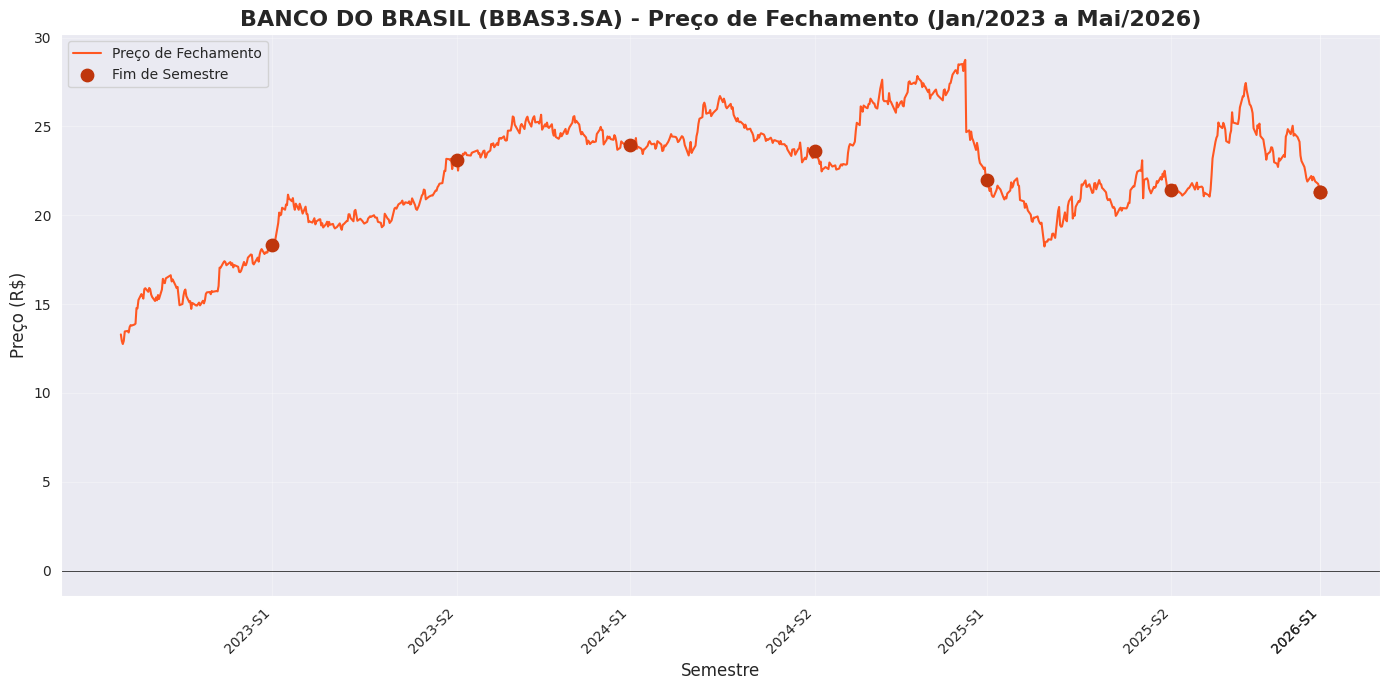

In [32]:
# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL (BBAS3.SA) ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais_bb = []
labels_semestrais_bb = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            # Tentar pegar o último dia do mês (junho ou dezembro)
            data_alvo_bb = pd.Timestamp(f"{ano}-{mes}-{mes}")
            # Buscar o maior índice <= data_alvo
            dados_semestre_bb = df_bb[df_bb.index <= data_alvo_bb]
            if not dados_semestre_bb.empty:
                ultima_data_bb = dados_semestre_bb.index[-1]
                pontos_semestrais_bb.append(ultima_data_bb)
                labels_semestrais_bb.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais_bb = [p for p in pontos_semestrais_bb if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig_bb, ax_bb = plt.subplots(figsize=(14, 7))

ax_bb.plot(df_bb.index, df_bb['Fechamento'], linewidth=1.5, color='#FF5722', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais_bb:
    valores_semestrais_bb = df_bb.loc[pontos_semestrais_bb, 'Fechamento']
    ax_bb.scatter(pontos_semestrais_bb, valores_semestrais_bb, color='#BF360C', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais_bb:
    ax_bb.set_xticks(pontos_semestrais_bb)
    ax_bb.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais_bb],
                       rotation=45, ha='right')

ax_bb.set_title('BANCO DO BRASIL (BBAS3.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax_bb.set_xlabel('Semestre', fontsize=12)
ax_bb.set_ylabel('Preço (R$)', fontsize=12)
ax_bb.legend(loc='upper left')
ax_bb.grid(True, alpha=0.3)
ax_bb.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [33]:
# ================== 7. TABELA RESUMO SEMESTRAL (BBAS3.SA) ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL (BBAS3.SA)")
print("="*80)

# Função para obter último dia de cada semestre (reutilizada e adaptada)
def get_ultimo_dia_semestre_bb(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem_bb = df[df.index <= data_fim]
    if not dados_sem_bb.empty:
        ultima_data_bb = dados_sem_bb.index[-1]
        return ultima_data_bb
    return None

tabela_semestral_bb = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data_bb = get_ultimo_dia_semestre_bb(df_bb, ano, sem);
        if ultima_data_bb and ultima_data_bb <= pd.Timestamp("2026-05-14"):
            dados_sem_periodo_bb = df_bb[df_bb.index.year == ano]
            if sem == 'S1':
                dados_sem_periodo_bb = dados_sem_periodo_bb[dados_sem_periodo_bb.index.month <= 6]
            else:
                dados_sem_periodo_bb = dados_sem_periodo_bb[dados_sem_periodo_bb.index.month > 6]

            if not dados_sem_periodo_bb.empty:
                abertura_bb = dados_sem_periodo_bb['Fechamento'].iloc[0]
                fechamento_bb = dados_sem_periodo_bb['Fechamento'].iloc[-1]
                media_bb = dados_sem_periodo_bb['Fechamento'].mean()
                desvio_bb = dados_sem_periodo_bb['Fechamento'].std()
                minimo_bb = dados_sem_periodo_bb['Fechamento'].min()
                maximo_bb = dados_sem_periodo_bb['Fechamento'].max()
                retorno_bb_calc = ((fechamento_bb - abertura_bb) / abertura_bb) * 100

                tabela_semestral_bb.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura_bb,
                    'Fechamento_R$': fechamento_bb,
                    'Média_R$': media_bb,
                    'Desvio_R$': desvio_bb,
                    'Mínimo_R$': minimo_bb,
                    'Máximo_R$': maximo_bb,
                    'Retorno_%': retorno_bb_calc
                })

df_tabela_bb = pd.DataFrame(tabela_semestral_bb)
print(df_tabela_bb.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA PARA BBAS3.SA!")
print("="*80)


📊 TABELA RESUMO SEMESTRAL (BBAS3.SA)
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        13.29          20.65     16.55       1.95      12.75      21.16      55.38
2023       S2        20.31          23.54     20.65       1.29      19.18      23.54      15.92
2024       S1        23.65          24.00     24.46       0.60      23.25      25.66       1.44
2024       S2        24.03          22.74     24.44       1.01      22.47      26.71      -5.36
2025       S1        22.81          21.39     25.31       2.27      20.89      28.75      -6.22
2025       S2        21.85          21.53     20.88       1.04      18.24      23.09      -1.46
2026       S1        21.81          21.33     23.75       1.65      21.05      27.45      -2.21

🎉 ANÁLISE CONCLUÍDA PARA BBAS3.SA!


In [34]:
# Estatísticas adicionais finais (BBAS3.SA)
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO (BBAS3.SA)")
print("="*80)
preco_inicial_bb = df_bb['Fechamento'].iloc[0]
preco_final_bb = df_bb['Fechamento'].iloc[-1]
retorno_total_bb = ((preco_final_bb - preco_inicial_bb) / preco_inicial_bb) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial_bb:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final_bb:.2f}")
print(f"Retorno Total no período: {retorno_total_bb:+.2f}%")
print(f"Volume Médio Diário: {df_bb['Volume'].mean():,.0f} ações")


📈 RESUMO FINAL DO PERÍODO (BBAS3.SA)
Preço Inicial (jan/2023): R$ 13.29
Preço Final (mai/2026): R$ 21.33
Retorno Total no período: +60.47%
Volume Médio Diário: 23,584,126 ações


# EXERCÍCIO: ANÁLISE COMPARATIVA DE AÇÕES BRASILEIRAS

## Contexto

Você é um analista financeiro e precisa avaliar o desempenho de 4 importantes empresas brasileiras no período de **janeiro de 2023 até 14 de maio de 2026**. As empresas e seus respectivos tickers são:

| Empresa | Ticker (Yahoo Finance) |
|---------|------------------------|
| Vale S.A. | VALE3.SA |
| Ambev S.A. | ABEV3.SA |
| Itaú Unibanco | ITUB4.SA |
| Banco do Brasil | BBAS3.SA |

## Objetivo

Para **cada uma das 4 empresas**, você deverá realizar as seguintes tarefas:

1. **Baixar os dados históricos** das ações no período solicitado utilizando a biblioteca `yfinance`

2. **Exibir as 5 primeiras e 5 últimas linhas** do DataFrame resultante (apenas as colunas de preços e volume)

3. **Calcular e exibir a média anual do preço de fechamento** para cada ano do período (2023, 2024, 2025 e 2026*)

4. **Calcular e exibir o desvio-padrão anual do preço de fechamento** para cada ano do período

5. **Calcular e exibir o retorno semestral** do preço de fechamento, mostrando a variação percentual entre semestres consecutivos (ex: 2023-S1 → 2023-S2, 2023-S2 → 2024-S1, etc.)

6. **Gerar um gráfico de linha do preço de fechamento** no período completo, com o eixo X rotulado apenas pelos semestres (ex: 2023-S1, 2023-S2, 2024-S1, etc.)